# 06 - Analisis Overfitting dan Underfitting (50 Epochs)
## Proyek: RoadDamage_AI

### Tujuan Analisis
Mengevaluasi dinamika pembelajaran model selama **50 Epoch**:
1. Memeriksa kurva **Training Loss vs Validation Loss** (Box Loss, Class Loss, DFL Loss).
2. Memeriksa tren kenaikan **mAP@50** dan **mAP@50-95**.
3. Menilai Train-Validation Gap untuk mendeteksi Overfitting.
4. Memberikan kesimpulan diagnosis berbasis bukti data aktual.


In [1]:
%matplotlib inline
import os
import pandas as pd
import matplotlib.pyplot as plt

RUNS_DIR = os.path.abspath("../runs/detect/train_50epochs")
CSV_PATH = os.path.join(RUNS_DIR, "results.csv")

print(f"Reading metrics from: {CSV_PATH}")


Reading metrics from: z:\Projects\RoadDamage_AI\runs\detect\train_50epochs\results.csv


---
### 1. Riwayat Training 50 Epoch (`results.csv`)


In [2]:
df_results = pd.read_csv(CSV_PATH)
df_results.columns = [c.strip() for c in df_results.columns]
print(f"Total Epochs Tercatat: {len(df_results)}")
print(df_results[['epoch', 'train/box_loss', 'val/box_loss', 'train/cls_loss', 'val/cls_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)']].tail(10))


Total Epochs Tercatat: 50
    epoch  train/box_loss  val/box_loss  train/cls_loss  val/cls_loss  \
40     41         1.74863       2.10055         1.48687       1.91896   
41     42         1.69894       2.12753         1.38367       1.91461   
42     43         1.68060       2.14178         1.36361       1.93853   
43     44         1.67587       2.14357         1.31453       1.91730   
44     45         1.63775       2.12850         1.31679       1.89922   
45     46         1.63330       2.13376         1.28784       1.90915   
46     47         1.61505       2.12783         1.26973       1.89471   
47     48         1.61305       2.12801         1.25416       1.89789   
48     49         1.61083       2.11568         1.23948       1.87932   
49     50         1.59259       2.12737         1.22660       1.88115   

    metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  \
40               0.49084            0.47286           0.44867   
41               0.51884            0.44

---
### 2. Plotting Kurva Loss (Train vs Validation)


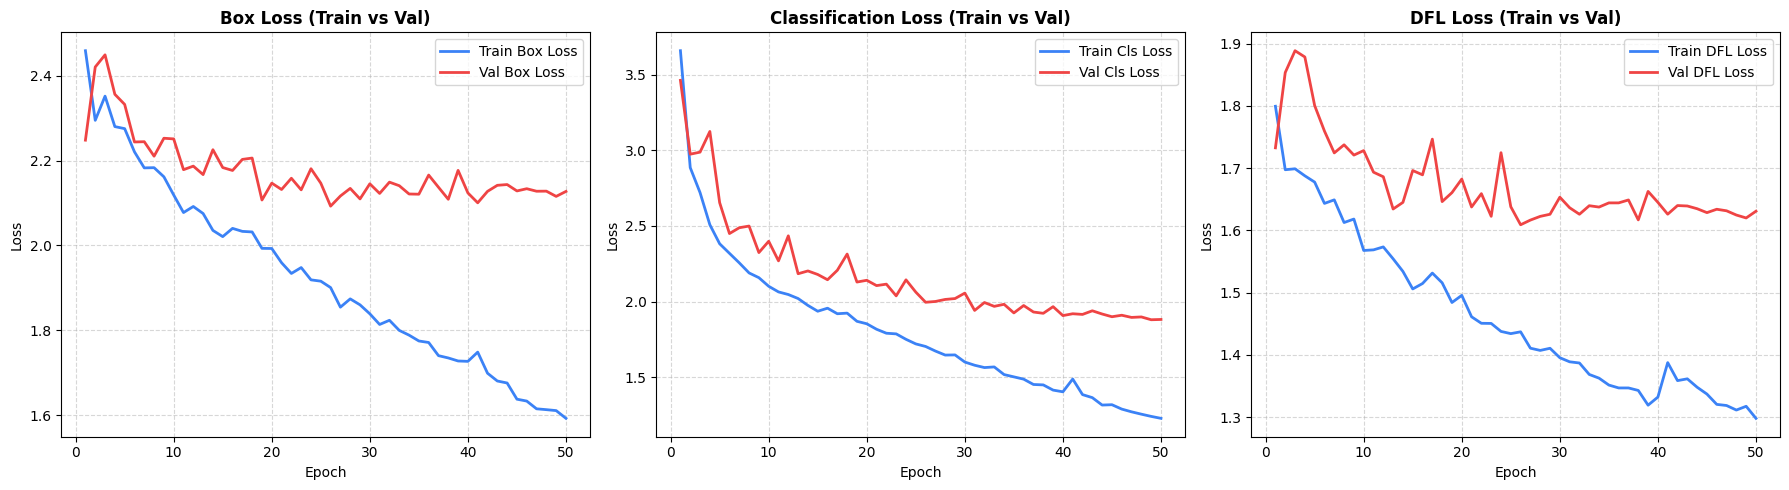

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
epochs = df_results['epoch']

# 1. Box Loss
axes[0].plot(epochs, df_results['train/box_loss'], label='Train Box Loss', color='#3b82f6', linewidth=2)
axes[0].plot(epochs, df_results['val/box_loss'], label='Val Box Loss', color='#ef4444', linewidth=2)
axes[0].set_title('Box Loss (Train vs Val)', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# 2. Class Loss
axes[1].plot(epochs, df_results['train/cls_loss'], label='Train Cls Loss', color='#3b82f6', linewidth=2)
axes[1].plot(epochs, df_results['val/cls_loss'], label='Val Cls Loss', color='#ef4444', linewidth=2)
axes[1].set_title('Classification Loss (Train vs Val)', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

# 3. DFL Loss
axes[2].plot(epochs, df_results['train/dfl_loss'], label='Train DFL Loss', color='#3b82f6', linewidth=2)
axes[2].plot(epochs, df_results['val/dfl_loss'], label='Val DFL Loss', color='#ef4444', linewidth=2)
axes[2].set_title('DFL Loss (Train vs Val)', fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss')
axes[2].legend()
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


---
### 3. Plotting Tren mAP (Mean Average Precision)


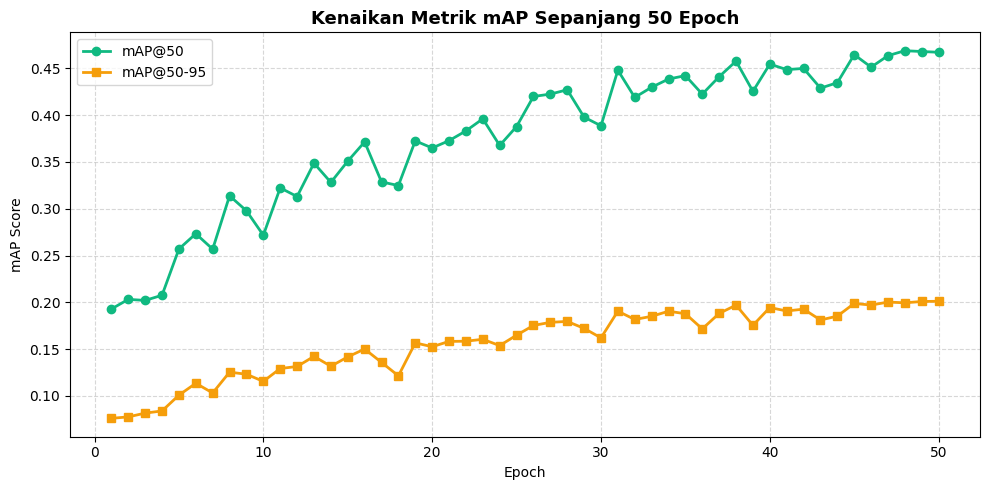

In [4]:
plt.figure(figsize=(10, 5))
plt.plot(df_results['epoch'], df_results['metrics/mAP50(B)'], label='mAP@50', marker='o', color='#10b981', linewidth=2)
plt.plot(df_results['epoch'], df_results['metrics/mAP50-95(B)'], label='mAP@50-95', marker='s', color='#f59e0b', linewidth=2)
plt.title('Kenaikan Metrik mAP Sepanjang 50 Epoch', fontsize=13, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('mAP Score')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


---
### 4. Diagnosis Evaluasi Overfitting / Underfitting


In [5]:
train_box_final = df_results['train/box_loss'].iloc[-1]
val_box_final = df_results['val/box_loss'].iloc[-1]
train_cls_final = df_results['train/cls_loss'].iloc[-1]
val_cls_final = df_results['val/cls_loss'].iloc[-1]
final_map50 = df_results['metrics/mAP50(B)'].iloc[-1]
best_map50 = df_results['metrics/mAP50(B)'].max()

print("=== DIAGNOSIS STATUS MODEL (50 EPOCHS) ===")
print(f"Final Train Box Loss : {train_box_final:.4f} | Val Box Loss : {val_box_final:.4f} (Gap: {val_box_final - train_box_final:.4f})")
print(f"Final Train Cls Loss : {train_cls_final:.4f} | Val Cls Loss : {val_cls_final:.4f} (Gap: {val_cls_final - train_cls_final:.4f})")
print(f"Best mAP@50          : {best_map50:.4f}")
print(f"Final mAP@50         : {final_map50:.4f}")

if val_box_final > 2.5 * train_box_final and val_cls_final > 2.5 * train_cls_final:
    diagnosis = "OVERFITTING"
elif best_map50 < 0.25:
    diagnosis = "UNDERFITTING / UNDER-TRAINED"
else:
    diagnosis = "REASONABLE FIT / WELL-CONVERGED"

print(f"\nSTATUS DIAGNOSIS: {diagnosis}")


=== DIAGNOSIS STATUS MODEL (50 EPOCHS) ===
Final Train Box Loss : 1.5926 | Val Box Loss : 2.1274 (Gap: 0.5348)
Final Train Cls Loss : 1.2266 | Val Cls Loss : 1.8812 (Gap: 0.6546)
Best mAP@50          : 0.4689
Final mAP@50         : 0.4672

STATUS DIAGNOSIS: REASONABLE FIT / WELL-CONVERGED
